## 0 — Install (run once, then restart runtime)

### Stability changes applied
- 5-fold CV kept unchanged
- lower source batch size with gradient accumulation
- mixed precision (`fp16`) enabled for source transformer training
- smaller embedding extraction batches to reduce OOM risk

Run each notebook in a fresh Colab runtime.

## 1 — Config & Drive

In [1]:
!python -m pip install -U pip
!python -m pip install "scipy>=1.14.1"

In [2]:
import os, json, warnings, numpy as np, torch
warnings.filterwarnings("ignore")

PRIMARY_CSV_PATH = "primary.csv"
TEXT_COL  = "text"
LABEL_COL = "category"

CFG = {
    "max_length"         : 128,
    "primary_num_labels" : 7,
    "n_folds"            : 5,
    "seed"               : 42,
    "output_dir"         : "output",
    "device"             : "cuda" if torch.cuda.is_available() else "cpu",
    "deberta_model"      : "microsoft/deberta-v3-base",
    "mpnet_model"        : "sentence-transformers/all-mpnet-base-v2",
    "setfit_model"       : "sentence-transformers/paraphrase-mpnet-base-v2",
    "lora_r"             : 16,
    "lora_alpha"         : 32,
    "lora_dropout"       : 0.1,
    "primary_epochs"     : 5,
    "primary_lr"         : 2e-4,
    "primary_batch_size" : 4,
    "grad_accum_steps"   : 4,
    "extract_batch_size" : 16,
    "use_fp16"           : True,
    "probe_epochs"       : 10,
    "probe_lr"           : 1e-3,
    "probe_batch_size"   : 32,
    "neural_epochs"      : 15,
    "neural_lr"          : 1e-3,
    "neural_batch_size"  : 32,
    "setfit_epochs"      : 1,
    "setfit_num_iters"   : 10,
    "ensemble_weights"   : [0.25, 0.45, 0.30],
}
os.makedirs(CFG["output_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
print(f"✅ Device: {CFG['device']}")

✅ Device: cpu


## 2 — Imports

In [3]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
from setfit import SetFitModel, Trainer
from datasets import load_dataset, Dataset as HFDataset
print("✅ Imports OK")

✅ Imports OK


## 3 — Shared Utilities

In [4]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

class LinearProbe(nn.Module):
    def __init__(self, in_dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_labels)
    def forward(self, x): return self.fc(x)

def make_result(name, accs, f1s):
    return dict(
        dataset=name,
        accuracy_mean=round(float(np.mean(accs)), 4),
        accuracy_std =round(float(np.std(accs)),  4),
        f1_mean      =round(float(np.mean(f1s)),  4),
        f1_std       =round(float(np.std(f1s)),   4),
        per_fold_acc =[round(a,4) for a in accs],
        per_fold_f1  =[round(f,4) for f in f1s],
    )

def print_result(model_name, ds_name, r):
    folds = r.get("per_fold_acc", [])
    fold_str = "  ".join([f"F{i+1}:{v:.4f}" for i,v in enumerate(folds)])
    print(f"  ► [{model_name}] {ds_name}: "
          f"acc={r['accuracy_mean']:.4f}±{r['accuracy_std']:.4f}  "
          f"f1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")
    print(f"    Per-fold acc: {fold_str}")

print("✅ Utilities ready")

✅ Utilities ready


## 4 — Load Primary Dataset

In [5]:
df = pd.read_csv(PRIMARY_CSV_PATH)
print(f"Loaded: {len(df)} rows | columns: {df.columns.tolist()}")
print(df[LABEL_COL].value_counts().sort_index())

primary_texts = df[TEXT_COL].astype(str).tolist()
le = LabelEncoder()
primary_labels = le.fit_transform(df[LABEL_COL].astype(str)).tolist()
CFG["primary_num_labels"] = len(le.classes_)
assert len(set(primary_labels)) == CFG["primary_num_labels"]
print(f"\n✅ {len(primary_texts)} samples, {len(set(primary_labels))} classes")

Loaded: 959 rows | columns: ['text', 'category']
category
Career Preparation             98
Extracurricular Activities    195
Facilities and Resources       88
Improvement Suggestions       202
Social Experience              86
Support Services               93
Teaching Quality              197
Name: count, dtype: int64

✅ 959 samples, 7 classes


## 5 — Load Target Datasets

In [6]:
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

def load_edura():
    ds    = load_dataset("yhua219/EduRABSA_SA")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    # Print columns so we can verify
    print(f"EduRABSA columns: {data.column_names}")
    
    texts  = [str(t) for t in data["text"]]
    
    # Try "output" first, fall back to other common names
    if "output" in data.column_names:
        raw_lb = [str(l).strip() for l in data["output"]]
    elif "sentiment" in data.column_names:
        raw_lb = [str(l).strip() for l in data["sentiment"]]
    elif "label" in data.column_names:
        raw_lb = [str(l).strip() for l in data["label"]]
    else:
        # Use last column as fallback
        col = data.column_names[-1]
        print(f"  Using fallback column: {col}")
        raw_lb = [str(l).strip() for l in data[col]]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if l not in ("", "nan", "None")]
    if len(pairs) == 0:
        raise ValueError("EduRABSA: all labels are empty — check column names above")
    
    texts, raw_lb = zip(*pairs)
    le = LabelEncoder()
    labels = le.fit_transform(list(raw_lb)).tolist()
    print(f"EduRABSA  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), labels, le.classes_.tolist()


def load_coursera(max_samples=3999):
    ds    = load_dataset("MungunshagaiT/coursera-reviews")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    texts  = [str(t) for t in data["text"]]
    raw_lb = list(data["label"])
    unique = sorted(set(raw_lb))
    
    if set(unique) == {0, 1, 2}:
        mapping = {0: "Negative", 1: "Positive", 2: "Neutral"}
        raw_lb = [mapping[v] for v in raw_lb]
    elif set(unique) == {0, 1}:
        raw_lb = ["Negative" if v == 0 else "Positive" for v in raw_lb]
    elif min(unique) >= 1 and max(unique) <= 5:
        raw_lb = ["Positive" if v >= 4 else ("Neutral" if v == 3 else "Negative") for v in raw_lb]
    else:
        raw_lb = [str(v) for v in raw_lb]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if str(l).strip() != ""]
    texts, raw_lb = zip(*pairs)
    
    le = LabelEncoder()
    labels_all = le.fit_transform(list(raw_lb)).tolist()
    
    if len(texts) > max_samples:
        texts, _, labels_all, _ = train_test_split(
            list(texts), labels_all, train_size=max_samples,
            random_state=CFG["seed"], stratify=labels_all)
    
    print(f"Coursera  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), list(labels_all), le.classes_.tolist()


# ── Load datasets ──────────────────────────────────────────
print("Loading target datasets...")
edura_texts,    edura_labels,    edura_classes    = load_edura()
coursera_texts, coursera_labels, coursera_classes = load_coursera(max_samples=10000)

TARGET_DATASETS = [
    ("EduRABSA", edura_texts,    edura_labels,    len(edura_classes)),
    ("Coursera", coursera_texts, coursera_labels, len(coursera_classes)),
]
print("\n✅ Target datasets ready")
print(f"   EduRABSA: {len(edura_texts)} samples | {edura_classes}")
print(f"   Coursera: {len(coursera_texts)} samples | {coursera_classes}")

# ── Class distribution ─────────────────────────────────────
for ds_name, texts, labels, classes in TARGET_DATASETS:
    # FIX: 'classes' is a list of names, not an integer
    class_names = edura_classes if ds_name == "EduRABSA" else coursera_classes
    counter = Counter(labels)
    total = len(labels)
    print(f"\n📊 {ds_name} class distribution ({total} samples):")
    for idx, cls_name in enumerate(class_names):  # FIX: iterate list not range
        count = counter.get(idx, 0)
        pct = count / total * 100
        bar = "█" * int(pct / 2)
        print(f"   {cls_name:<12} : {count:>5} samples ({pct:5.1f}%)  {bar}")

Loading target datasets...
EduRABSA columns: ['id', 'task_type', 'original_id', 'text', 'output']
EduRABSA  | 3999 samples | classes: ['negative', 'neutral', 'positive']
Coursera  | 10000 samples | classes: ['Negative', 'Neutral', 'Positive']

✅ Target datasets ready
   EduRABSA: 3999 samples | ['negative', 'neutral', 'positive']
   Coursera: 10000 samples | ['Negative', 'Neutral', 'Positive']

📊 EduRABSA class distribution (3999 samples):
   negative     :   954 samples ( 23.9%)  ███████████
   neutral      :   953 samples ( 23.8%)  ███████████
   positive     :  2092 samples ( 52.3%)  ██████████████████████████

📊 Coursera class distribution (10000 samples):
   Negative     :   441 samples (  4.4%)  ██
   Neutral      :  4543 samples ( 45.4%)  ██████████████████████
   Positive     :  5016 samples ( 50.2%)  █████████████████████████


## 6 — Transformer Utilities (Shared)

In [7]:
class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_labels, lora_cfg=None):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        if lora_cfg:
            lc = LoraConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                r=lora_cfg["r"], lora_alpha=lora_cfg["alpha"],
                lora_dropout=lora_cfg["dropout"],
                target_modules=lora_cfg.get("targets", ["query","value"]),
                bias="none"
            )
            self.encoder = get_peft_model(self.encoder, lc)
            self.encoder.print_trainable_parameters()
        self.hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(self.hidden, num_labels))

    def forward(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.head(out.last_hidden_state[:,0,:])

    @torch.no_grad()
    def get_cls(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:,0,:]

def finetune_on_primary(model_name, primary_texts, primary_labels, cfg, lora_cfg=None):
    device = cfg["device"]
    tok = AutoTokenizer.from_pretrained(model_name)
    model = TransformerClassifier(model_name, cfg["primary_num_labels"], lora_cfg).to(device)

    tr_t, va_t, tr_l, va_l = train_test_split(
        primary_texts, primary_labels,
        test_size=0.2,
        random_state=cfg["seed"],
        stratify=primary_labels
    )

    tr_dl = DataLoader(
        TextDataset(tr_t, tr_l, tok, cfg["max_length"]),
        batch_size=cfg["primary_batch_size"],
        shuffle=True
    )
    va_dl = DataLoader(
        TextDataset(va_t, va_l, tok, cfg["max_length"]),
        batch_size=cfg["primary_batch_size"],
        shuffle=False
    )

    total_steps = max(1, (len(tr_dl) * cfg["primary_epochs"]) // cfg["grad_accum_steps"])
    opt = AdamW(model.parameters(), lr=cfg["primary_lr"], weight_decay=0.01)
    sch = get_linear_schedule_with_warmup(opt, int(0.1 * total_steps), total_steps)

    use_amp = cfg.get("use_fp16", False) and device == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_f1, best_state = 0.0, None
    print(f"  Fine-tuning {model_name} on primary ({cfg['primary_epochs']} epochs)...")

    for ep in range(1, cfg["primary_epochs"] + 1):
        model.train()
        opt.zero_grad()

        for step, batch in enumerate(tr_dl, 1):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(ids, mask)
                loss = nn.CrossEntropyLoss()(logits, lbl)
                loss = loss / cfg["grad_accum_steps"]

            scaler.scale(loss).backward()

            if step % cfg["grad_accum_steps"] == 0 or step == len(tr_dl):
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                sch.step()
                opt.zero_grad()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in va_dl:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(ids, mask)
                preds.extend(logits.argmax(-1).cpu().tolist())
                trues.extend(batch["labels"].tolist())

        vf1 = f1_score(trues, preds, average="macro", zero_division=0)
        print(f"    Epoch {ep}/{cfg['primary_epochs']}: val_f1={vf1:.4f}")

        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if device == "cuda":
            torch.cuda.empty_cache()

    model.load_state_dict(best_state)

    for p in model.encoder.parameters():
        p.requires_grad = False

    print(f"  Encoder frozen ✅ (best val_f1={best_f1:.4f})")
    return model, tok

@torch.no_grad()
def extract_cls_embeddings(model, texts, tok, cfg):
    model.eval()
    ds = TextDataset(texts, [0]*len(texts), tok, cfg["max_length"])
    dl = DataLoader(ds, batch_size=cfg["extract_batch_size"], shuffle=False)
    out = []
    use_amp = cfg.get("use_fp16", False) and cfg["device"] == "cuda"

    for batch in dl:
        ids = batch["input_ids"].to(cfg["device"])
        mask = batch["attention_mask"].to(cfg["device"])
        with torch.cuda.amp.autocast(enabled=use_amp):
            emb = model.get_cls(ids, mask)
        out.append(emb.cpu().float().numpy())

        del ids, mask, emb
        if cfg["device"] == "cuda":
            torch.cuda.empty_cache()

    return np.vstack(out)

def linear_probe_cv(embeddings, labels, num_labels, ds_name, model_name, cfg):
    device = cfg["device"]
    labels = np.array(labels)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    accs, f1s = [], []
    print(f"  [{model_name}] Frozen encoder → linear probe 5-fold CV on {ds_name}")

    for fold, (tri, tei) in enumerate(skf.split(embeddings, labels), 1):
        X_tr = torch.tensor(embeddings[tri], dtype=torch.float32)
        y_tr = torch.tensor(labels[tri], dtype=torch.long)
        X_te = torch.tensor(embeddings[tei], dtype=torch.float32)
        y_te_np = labels[tei]

        tr_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=cfg["probe_batch_size"], shuffle=True)

        probe = LinearProbe(embeddings.shape[1], num_labels).to(device)
        opt = AdamW(probe.parameters(), lr=cfg["probe_lr"], weight_decay=1e-4)
        # ── Class weights for imbalanced target datasets ──
        from sklearn.utils.class_weight import compute_class_weight as _ccw
        import numpy as _np
        _cls = _np.unique(labels[tri])
        _cw  = _ccw("balanced", classes=_cls, y=labels[tri])
        _cwt = torch.tensor(_cw, dtype=torch.float32).to(device)
        crit = nn.CrossEntropyLoss(weight=_cwt)
        # ─────────────────────────────────────────────────

        for _ in range(cfg["probe_epochs"]):
            probe.train()
            for xb, yb in tr_dl:
                xb, yb = xb.to(device), yb.to(device)
                loss = crit(probe(xb), yb)
                opt.zero_grad()
                loss.backward()
                opt.step()

        probe.eval()
        with torch.no_grad():
            preds = probe(X_te.to(device)).argmax(-1).cpu().tolist()

        accs.append(accuracy_score(y_te_np, preds))
        f1s.append(f1_score(y_te_np, preds, average="macro", zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")

        del X_tr, y_tr, X_te, probe
        if device == "cuda":
            torch.cuda.empty_cache()

    r = make_result(ds_name, accs, f1s)
    print_result(model_name, ds_name, r)
    return r

print("✅ Transformer utilities ready")

✅ Transformer utilities ready


## 7 — Model 5: DeBERTa-LoRA

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
os.environ["WANDB_DISABLED"] = "true"

In [9]:
print("=" * 65)
print("MODEL 5: DeBERTa-LoRA")
print("  Step 1: Fine-tune on primary (LoRA adapters only)")
print("  Step 2: Freeze entire encoder (LoRA included)")
print("  Step 3: Linear probe on each target dataset (5-fold CV)")
print("=" * 65)

lora_cfg = {"r":CFG["lora_r"],"alpha":CFG["lora_alpha"],
            "dropout":CFG["lora_dropout"],"targets":["query_proj","value_proj"]}

deberta_model, deberta_tok = finetune_on_primary(
    CFG["deberta_model"], primary_texts, primary_labels, CFG, lora_cfg=lora_cfg)

results_deberta = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    print(f"  Extracting DeBERTa CLS embeddings for {name}...")
    embs = extract_cls_embeddings(deberta_model, texts, deberta_tok, CFG)
    print(f"  Embedding shape: {embs.shape}")
    results_deberta[name] = linear_probe_cv(embs, labels, n_cls, name, "DeBERTa-LoRA", CFG)
print("\n✅ DeBERTa-LoRA done")

MODEL 5: DeBERTa-LoRA
  Step 1: Fine-tune on primary (LoRA adapters only)
  Step 2: Freeze entire encoder (LoRA included)
  Step 3: Linear probe on each target dataset (5-fold CV)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/opt/anaconda3/lib/python3.13/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


trainable params: 589,824 || all params: 184,421,376 || trainable%: 0.3198
  Fine-tuning microsoft/deberta-v3-base on primary (5 epochs)...
    Epoch 1/5: val_f1=0.0567
    Epoch 2/5: val_f1=0.1525
    Epoch 3/5: val_f1=0.1973
    Epoch 4/5: val_f1=0.2177
    Epoch 5/5: val_f1=0.2205
  Encoder frozen ✅ (best val_f1=0.2205)
  Extracting DeBERTa CLS embeddings for EduRABSA...
  Embedding shape: (3999, 768)
  [DeBERTa-LoRA] Frozen encoder → linear probe 5-fold CV on EduRABSA
    Fold 1: acc=0.7375  f1=0.7078
    Fold 2: acc=0.7425  f1=0.6979
    Fold 3: acc=0.6850  f1=0.6214
    Fold 4: acc=0.6950  f1=0.6792
    Fold 5: acc=0.7472  f1=0.7135
  ► [DeBERTa-LoRA] EduRABSA: acc=0.7214±0.0260  f1=0.6840±0.0334
    Per-fold acc: F1:0.7375  F2:0.7425  F3:0.6850  F4:0.6950  F5:0.7472
  Extracting DeBERTa CLS embeddings for Coursera...
  Embedding shape: (10000, 768)
  [DeBERTa-LoRA] Frozen encoder → linear probe 5-fold CV on Coursera
    Fold 1: acc=0.4710  f1=0.4598
    Fold 2: acc=0.4385  f1=0.

## 8 — Save Results

In [10]:
import json
out = {"DeBERTa-LoRA": results_deberta}
out_path = f"{CFG['output_dir']}/results_deberta.json"
with open(out_path,"w") as f: json.dump(out, f, indent=2)
print(f"✅ Saved → {out_path}")

✅ Saved → output/results_deberta.json


In [11]:
import os
import torch

SAVE_DIR = "saved_models/deberta_lora_encoder"
os.makedirs(SAVE_DIR, exist_ok=True)

# save model weights
torch.save(deberta_model.state_dict(), os.path.join(SAVE_DIR, "model_state_dict.pt"))

# save tokenizer
deberta_tok.save_pretrained(SAVE_DIR)

print("✅ Custom DeBERTa model state_dict and tokenizer saved")

✅ Custom DeBERTa model state_dict and tokenizer saved


## — Results Table


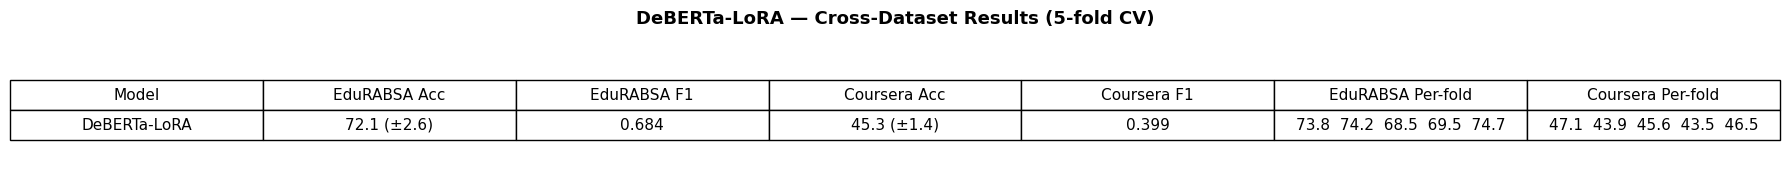

✅ Saved → output/results_table_deberta.png


In [12]:
import matplotlib.pyplot as plt

all_models = [("DeBERTa-LoRA", results_deberta, "Transformer")]

rows = []
for mname, rdict, group in all_models:
    edu = rdict.get("EduRABSA", {})
    cou = rdict.get("Coursera",  {})
    def fmt_acc(r):
        m, s = r.get("accuracy_mean",0)*100, r.get("accuracy_std",0)*100
        return f"{m:.1f} (±{s:.1f})"
    def fmt_f1(r):
        return f"{r.get('f1_mean',0):.3f}"
    def fmt_folds(r):
        folds = r.get("per_fold_acc", [])
        return "  ".join([f"{v*100:.1f}" for v in folds]) if folds else "—"
    rows.append([
        mname,
        fmt_acc(edu), fmt_f1(edu),
        fmt_acc(cou), fmt_f1(cou),
        fmt_folds(edu), fmt_folds(cou),
    ])

col_labels = [
    "Model",
    "EduRABSA Acc", "EduRABSA F1",
    "Coursera Acc", "Coursera F1",
    "EduRABSA Per-fold", "Coursera Per-fold"
]

fig, ax = plt.subplots(figsize=(18, 2))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

plt.title("DeBERTa-LoRA — Cross-Dataset Results (5-fold CV)",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
out_png = f"{CFG['output_dir']}/results_table_deberta.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✅ Saved → {out_png}")